<a href="https://colab.research.google.com/github/roeiyanku/UAV_Sound_Classification_Project/blob/main/notebooks/02_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading
### This section outlines the process of loading and preprocessing audio data for feature extraction. The goal is to prepare the audio for various machine learning models.

This code cell ensures the notebook's metadata is properly formatted. Specifically, it removes a common metadata entry (`'widgets'`) that can sometimes cause issues or warnings when opening the notebook in different environments. This helps maintain consistency and prevents potential errors, particularly when collaborating or moving notebooks between Colab and other Jupyter-like environments. You typically only need to run this cell once per notebook session if you encounter metadata-related issues.

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import json

path = "/content/drive/MyDrive/Final Project RMOT/notebooks/02_feature_extraction.ipynb"

with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

nb["metadata"].pop("widgets", None)

with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("Fixed notebook metadata")

Fixed notebook metadata


### 0) Paths & Constants

In [6]:
# ── All paths and settings are defined here ──────────────────────────────────

DATASET = "Multiclass_Drone_Audio"      # "fan", "pump", "slider", "valve", "Binary_Drone_Audio", "AeroSonicDB", "Multiclass_Drone_Audio"
DB_LEVEL = "0_dB"
ID = "id_00"

#SPLITS_PATH = f"/content/drive/MyDrive/Final Project RMOT/MIMII_dataset/processed/splits/{DATASET}/{DB_LEVEL}/{ID}/processed_audio_splits.joblib"
SPLITS_PATH =  f"/content/drive/MyDrive/Final Project RMOT/processed/splits/Multiclass_Drone_Audio/processed_audio_splits.joblib"

#FEATURES_SAVE_DIR = f"/content/drive/MyDrive/Final Project RMOT/MIMII_dataset/processed/features/{DATASET}/{DB_LEVEL}/{ID}"
FEATURES_SAVE_DIR = f"/content/drive/MyDrive/Final Project RMOT/processed/features/Multiclass_Drone_Audio"


# Set to True to augment training data before extracting features
APPLY_AUGMENTATION = False

if APPLY_AUGMENTATION:
    #FEATURES_SAVE_DIR = f"/content/drive/MyDrive/Final Project RMOT/MIMII_dataset/processed/augmented/{DATASET}/{DB_LEVEL}/{ID}"
    FEATURES_SAVE_DIR = f"/content/drive/MyDrive/Final Project RMOT/processed/augmented/Multiclass_Drone_Audio"
else:
    #FEATURES_SAVE_DIR = f"/content/drive/MyDrive/Final Project RMOT/MIMII_dataset/processed/features/{DATASET}/{DB_LEVEL}/{ID}"
    FEATURES_SAVE_DIR = f"/content/drive/MyDrive/Final Project RMOT/processed/features/Multiclass_Drone_Audio"


RANDOM_STATE         = 42
SAMPLE_RATE          = 16000
CLIP_SECONDS         = 1 #Changed for specific dataset
N_MELS               = 64
TF_BATCH_SIZE        = 32
EMBEDDING_BATCH_SIZE = 4
CNN_EPOCHS           = 10

AUG_TYPES = ['time_stretch', 'pitch_shift', 'add_noise',
             'time_shift',   'gain',         'spec_augment']

### Import Dependencies
This cell imports all necessary Python libraries for audio processing, deep learning models (TensorFlow and PyTorch), and utilities like `joblib` for data loading. Key libraries include `librosa` for audio manipulation, `tensorflow` for dataset creation, and `transformers` for pre-trained AST and Wav2Vec2 models.

In [8]:
pip install tensorflow tensorflow-hub tensorflow-io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 119.7 MB/s eta 0:00:00


In [9]:
import os
import time
import joblib
import numpy as np
import librosa
import tensorflow as tf
import torch
import tensorflow_hub as hub
import numpy as np


from transformers import (
    AutoFeatureExtractor,
    ASTForAudioClassification,
    Wav2Vec2Processor,
    Wav2Vec2Model,
)

### Mount Drive and Load Prepared Data
This section mounts Google Drive to access stored data and then loads pre-processed audio splits (`X_train`, `y_train`, etc.) from a `joblib` file. These splits contain file paths to audio samples and their corresponding labels, ready for feature extraction and model training.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
data = joblib.load(SPLITS_PATH)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

In [11]:
print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 8192 samples
Validation set size: 1756 samples
Test set size: 1756 samples


### Define Constants

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


### Audio Preprocessing Functions
- `load_waveform`: Loads an audio file and pads/trims it to a fixed duration.
- `Data Augmentation` : Defines 6 augmentation types that can be applied to waveforms during feature extraction in the next notebook.


In [13]:
def load_waveform(path, sr=SAMPLE_RATE, seconds=CLIP_SECONDS):
    """Load one audio file, then pad or trim it to a fixed length."""
    audio, _ = librosa.load(path, sr=sr, mono=True)
    target_len = sr * seconds

    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    return audio.astype(np.float32)


def augment_waveform(y, sr, aug_type):
    """
    Apply one of 6 augmentation strategies to a waveform.

    Parameters
    ----------
    y        : np.ndarray – raw waveform
    sr       : int        – sample rate
    aug_type : str        – one of:
                 'time_stretch', 'pitch_shift', 'add_noise',
                 'time_shift',   'gain',         'spec_augment'

    Returns
    -------
    np.ndarray – augmented waveform (same length as input)
    """
    rng = np.random.default_rng()

    if aug_type == 'time_stretch':
        rate = rng.uniform(0.9, 1.1)
        y = librosa.effects.time_stretch(y, rate=rate)

    elif aug_type == 'pitch_shift':
        n_steps = rng.uniform(-2, 2)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

    elif aug_type == 'add_noise':
        noise = 0.005 * rng.standard_normal(len(y))
        y = y + noise.astype(y.dtype)

    elif aug_type == 'time_shift':
        shift = int(rng.uniform(0, 0.5) * len(y))
        y = np.roll(y, shift)

    elif aug_type == 'gain':
        factor = rng.uniform(0.7, 1.3)
        y = (y * factor).astype(y.dtype)

    elif aug_type == 'spec_augment':
        S = librosa.stft(y)
        n_freq, n_frames = S.shape
        f0 = rng.integers(0, n_freq // 2)
        S[f0 : f0 + rng.integers(1, max(2, n_freq // 8)), :] = 0
        t0 = rng.integers(0, n_frames // 2)
        S[:, t0 : t0 + rng.integers(1, max(2, n_frames // 8))] = 0
        y = librosa.istft(S, length=len(y))

    else:
        raise ValueError(f"Unknown aug_type: {aug_type!r}")

    return y.astype(np.float32)

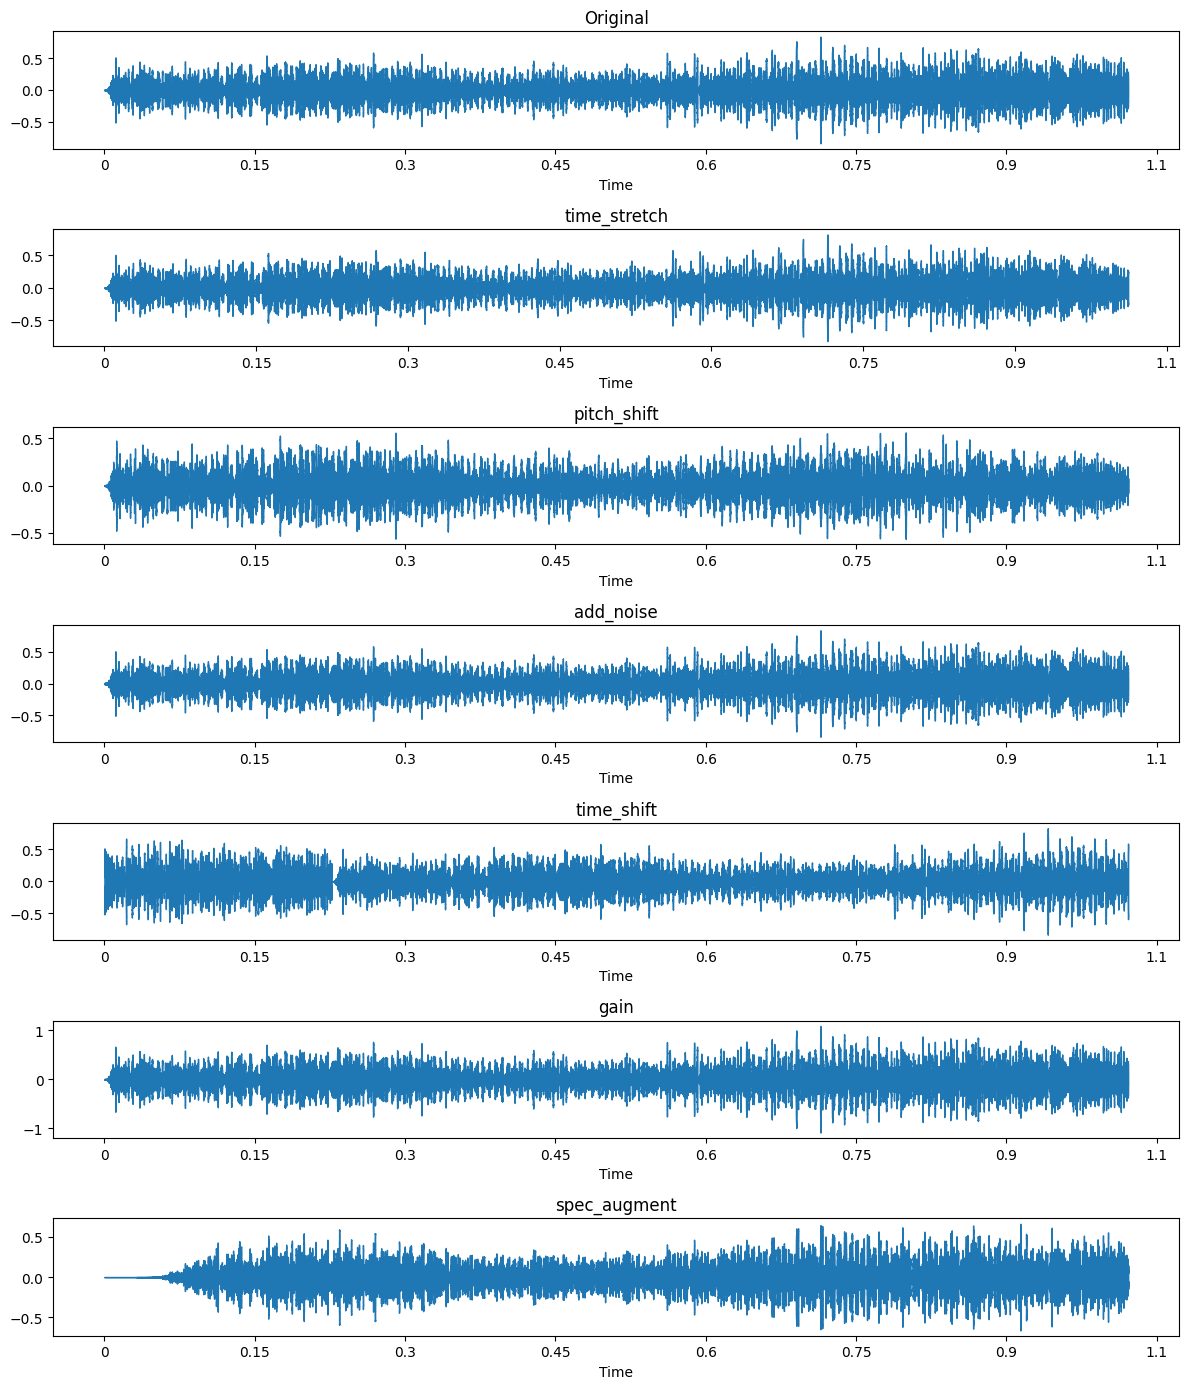

In [14]:
# Quick preview of all 6 types on the first training file

import matplotlib.pyplot as plt
import librosa.display

sample_path = X_train[0]
y_orig, sr_orig = librosa.load(sample_path, sr=None)

aug_types = ['time_stretch', 'pitch_shift', 'add_noise',
             'time_shift',   'gain',         'spec_augment']

fig, axes = plt.subplots(len(aug_types) + 1, 1, figsize=(12, 14))
librosa.display.waveshow(y_orig, sr=sr_orig, ax=axes[0])
axes[0].set_title("Original")

for ax, aug in zip(axes[1:], aug_types):
    y_aug = augment_waveform(y_orig.copy(), sr_orig, aug)
    librosa.display.waveshow(y_aug, sr=sr_orig, ax=ax)
    ax.set_title(aug)

plt.tight_layout()
plt.show()

### Augment Training Data

Build an expanded training set by appending augmented copies of each training file.



In [ ]:
if APPLY_AUGMENTATION:
    print("Augmenting training data...")
    aug_X_train, aug_y_train = [], []

    for path, label in zip(X_train, y_train):
        # keep original
        aug_X_train.append(path)
        aug_y_train.append(label)
        # add one augmented copy per aug type
        for aug in AUG_TYPES:
            aug_X_train.append(path)
            aug_y_train.append(label)

    print(f"Training set: {len(X_train)} -> {len(aug_X_train)} samples")
    X_train_final = aug_X_train
    y_train_final = aug_y_train
else:
    X_train_final = X_train
    y_train_final = y_train

## Feature Extractors

### Acoustic Spectrogram Transformer (AST) Feature Extraction
This section defines and executes the `extract_ast_features` function. This function utilizes a pre-trained AST model from Hugging Face Transformers to extract high-level features from audio waveforms. It processes audio in batches, leveraging the `AutoFeatureExtractor` and `ASTForAudioClassification` models, and computes the mean of the last hidden states as features. The extracted features for training, validation, and test sets are then printed.

In [ ]:
def extract_ast_features(paths, batch_size=EMBEDDING_BATCH_SIZE):
    feature_extractor = AutoFeatureExtractor.from_pretrained(
        "MIT/ast-finetuned-audioset-10-10-0.4593"
    )
    ast_model = ASTForAudioClassification.from_pretrained(
        "MIT/ast-finetuned-audioset-10-10-0.4593"
    ).to(device)
    ast_model.eval()

    features = []

    for start_idx in range(0, len(paths), batch_size):
        batch_paths = paths[start_idx:start_idx + batch_size]
        batch_audio = [load_waveform(path) for path in batch_paths]

        inputs = feature_extractor(
            batch_audio,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
        )
        inputs = {key: value.to(device) for key, value in inputs.items()}

        with torch.no_grad():
            outputs = ast_model(**inputs, output_hidden_states=True)
            hidden_states = outputs.hidden_states[-1]
            batch_features = hidden_states.mean(dim=1).detach().cpu().numpy()

        features.append(batch_features)

    return np.vstack(features)


ast_start = time.time()
ast_train_features = extract_ast_features(X_train)
ast_val_features = extract_ast_features(X_val)
ast_test_features = extract_ast_features(X_test)

ast_train_time = time.time() - ast_start

print("AST feature shapes:", ast_train_features.shape, ast_val_features.shape, ast_test_features.shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

AST feature shapes: (8192, 768) (1756, 768) (1756, 768)


### Wav2Vec2 Feature Extraction
Similar to the AST section, this block defines and executes the `extract_wav2vec_features` function. This function uses a pre-trained Wav2Vec2 model to extract audio features from raw waveforms. It uses `Wav2Vec2Processor` to prepare the audio and `Wav2Vec2Model` to obtain hidden states, which are then averaged to form the final features. The extracted features for training, validation, and test sets are printed along with the time taken for extraction.

In [ ]:
def extract_wav2vec_features(paths, batch_size=EMBEDDING_BATCH_SIZE):
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
    wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device)
    wav2vec_model.eval()

    features = []

    for start_idx in range(0, len(paths), batch_size):
        batch_paths = paths[start_idx:start_idx + batch_size]
        batch_audio = [load_waveform(path) for path in batch_paths]

        inputs = processor(
            batch_audio,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            padding=True,
        )

        input_values = inputs.input_values.to(device)
        attention_mask = (
            inputs.attention_mask.to(device)
            if hasattr(inputs, "attention_mask")
            else None
        )

        with torch.no_grad():
            outputs = wav2vec_model(
                input_values=input_values,
                attention_mask=attention_mask,
            )
            hidden_states = outputs.last_hidden_state
            batch_features = hidden_states.mean(dim=1).detach().cpu().numpy()

        features.append(batch_features)

    return np.vstack(features)


wav2vec_start = time.time()
wav2vec_train_features = extract_wav2vec_features(X_train)
wav2vec_val_features = extract_wav2vec_features(X_val)
wav2vec_test_features = extract_wav2vec_features(X_test)

wav2vec_train_time = time.time() - wav2vec_start

print("Wav2Vec2 feature shapes:", wav2vec_train_features.shape, wav2vec_val_features.shape, wav2vec_test_features.shape)


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2 feature shapes: (8192, 768) (1756, 768) (1756, 768)


### logmel Feature Extraction


In [ ]:
def extract_logmel_features(paths, sample_rate=SAMPLE_RATE, n_mels=64, duration=2.0):
    features = []
    target_len = int(sample_rate * duration)

    for path in paths:
        y, sr = librosa.load(path, sr=sample_rate)

        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels
        )

        logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
        features.append(logmel)

    return np.stack(features).astype(np.float32)

logmel_start = time.time()
logmel_train_features = extract_logmel_features(X_train)
logmel_val_features = extract_logmel_features(X_val)
logmel_test_features = extract_logmel_features(X_test)

logmel_train_time = time.time() - logmel_start

print(
    "Log-Mel feature shapes:",
    logmel_train_features.shape,
    logmel_val_features.shape,
    logmel_test_features.shape
)

Log-Mel feature shapes: (8192, 64, 63) (1756, 64, 63) (1756, 64, 63)


###YAMnet Feature Extractor


This section defines the `extract_yamnet_embedding` function, which leverages the pre-trained YAMnet model from TensorFlow Hub. This function processes raw audio waveforms, normalizes them, and then uses YAMnet to produce a 1024-dimensional embedding that captures the acoustic characteristics of the sound. These embeddings serve as high-level features for subsequent machine learning tasks.

In [17]:
yamnet_model = hub.load(
    'https://tfhub.dev/google/yamnet/1'
)

def extract_yamnet_embedding(audio_path):

    waveform = load_waveform(audio_path)

    #normalize amplitude
    max_val = np.max(np.abs(waveform))
    if max_val > 0:
      wavform = waveform / max_val

    waveform = waveform.astype(np.float32)

    scores, embeddings, spectrogram = yamnet_model(waveform)

    embedding = np.mean(
        embeddings.numpy(),
        axis=0
    )

    return embedding

In [ ]:
yamnet_start = time.time()

yamnet_train_features = np.array([extract_yamnet_embedding(path) for path in X_train])
yamnet_val_features = np.array([extract_yamnet_embedding(path) for path in X_val])
yamnet_test_features = np.array([extract_yamnet_embedding(path) for path in X_test])

yamnet_train_time = time.time() - yamnet_start

print(
    "YAMnet feature shapes:",
    yamnet_train_features.shape,
    yamnet_val_features.shape,
    yamnet_test_features.shape
)

YAMnet feature shapes: (8192, 1024) (1756, 1024) (1756, 1024)


## Triplet Loss Setup and Training

This section defines the components for training a model using triplet loss: the triplet loss function itself, a strategy for mining triplets from the dataset, an embedding network, and the training loop.

### Triplet Loss Function

Triplet Loss is a loss function used in machine learning for learning embeddings where the goal is to make anchor and positive examples closer to each other than anchor and negative examples.

The core idea is to minimize the distance between an anchor sample ($A$) and a positive sample ($P$) (which belongs to the same class as the anchor) while maximizing the distance between the anchor sample ($A$) and a negative sample ($N$) (which belongs to a different class than the anchor). A margin parameter is used to enforce a minimum separation between the positive and negative pairs.

Mathematically, the triplet loss for a given triplet $(A, P, N)$ is defined as:

$L(A, P, N) = \text{max}(0, D(A, P) - D(A, N) + \text{margin})$

where $D$ is a distance metric (e.g., Euclidean distance or cosine distance).

In [ ]:
import tensorflow as tf

def triplet_loss(anchor, positive, negative, margin=0.5):
    """
    Calculates the triplet loss.

    Parameters:
    - anchor: Embedding of the anchor sample.
    - positive: Embedding of the positive sample (same class as anchor).
    - negative: Embedding of the negative sample (different class from anchor).
    - margin: A non-negative value that enforces a minimum distance between (anchor, positive) and (anchor, negative) pairs.

    Returns:
    - A scalar tensor representing the triplet loss.
    """
    # Calculate Euclidean distances
    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)

    # Triplet loss formula
    loss = tf.maximum(0.0, pos_dist - neg_dist + margin)
    return tf.reduce_mean(loss)

print("Triplet loss function defined.")

Triplet loss function defined.


### Triplet Mining

Triplet mining is the process of selecting effective (anchor, positive, negative) triplets from your dataset. The goal is to choose triplets that contribute most to the learning process, often by selecting 'hard' triplets (where the negative is close to the anchor, or the positive is far from the anchor) to make the model work harder to distinguish between classes.

There are several strategies for triplet mining:

*   **Online mining**: Triplets are generated on the fly within each mini-batch during training. This can be more efficient as it doesn't require pre-calculating all possible triplets.
*   **Offline mining**: Triplets are generated once before training and then used throughout the training process. This can be computationally expensive for large datasets.
*   **Hard negative mining**: Focuses on selecting negative samples that are challenging for the model to distinguish from the anchor (i.e., $D(A, P) - D(A, N) + \text{margin}$ is positive, or close to zero).

For this, we'll implement a simple online triplet mining strategy: for each anchor, we'll randomly select one positive sample (from the same class) and one negative sample (from a different class).

In [ ]:
import random
import numpy as np

def get_triplets(embeddings, labels, num_triplets=100):
    """
    Generates triplets (anchor, positive, negative) for triplet loss.
    This method uses online mining.

    Parameters:
    - embeddings: A numpy array of features/embeddings (e.g., yamnet_train_features).
    - labels: A list or numpy array of corresponding labels (e.g., y_train_final).
    - num_triplets: The number of triplets to generate.

    Returns:
    - A list of tuples, where each tuple contains (anchor_embedding, positive_embedding, negative_embedding).
    """
    triplets = []
    labels_np = np.array(labels)
    unique_labels = np.unique(labels_np)

    if len(unique_labels) < 2:
        raise ValueError("Cannot form triplets: need at least two distinct classes.")

    for _ in range(num_triplets):
        # Select an anchor class
        anchor_class = random.choice(unique_labels)
        anchor_indices = np.where(labels_np == anchor_class)[0]

        if len(anchor_indices) < 2:
            # Not enough samples for anchor and positive from this class
            continue

        # Select anchor and positive
        anchor_idx, positive_idx = random.sample(list(anchor_indices), 2)
        anchor_embedding = embeddings[anchor_idx]
        positive_embedding = embeddings[positive_idx]

        # Select a negative class (different from anchor class)
        negative_class = random.choice([c for c in unique_labels if c != anchor_class])
        negative_indices = np.where(labels_np == negative_class)[0]

        if len(negative_indices) == 0:
            # No samples for the chosen negative class
            continue

        # Select negative
        negative_idx = random.choice(list(negative_indices))
        negative_embedding = embeddings[negative_idx]

        triplets.append((anchor_embedding, positive_embedding, negative_embedding))

    return triplets

print("Triplet mining function defined.")

Triplet mining function defined.


### Build an Embedded Network

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Define a custom Keras layer for L2 normalization
class L2NormalizationLayer(layers.Layer):
    def __init__(self, axis=-1, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({
            'axis': self.axis,
        })
        return config

def create_embedding_model(input_dim, embedding_dim=128):

    inputs = tf.keras.Input(shape=(input_dim,))

    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(embedding_dim)(x)

    # Use the custom L2 normalization layer
    outputs = L2NormalizationLayer(axis=1)(x)

    model = Model(inputs, outputs)

    return model

In [ ]:
import numpy as np

def prepare_triplet_data(triplets):

    anchors = np.array([t[0] for t in triplets])
    positives = np.array([t[1] for t in triplets])
    negatives = np.array([t[2] for t in triplets])

    return anchors, positives, negatives

In [ ]:
def train_triplet_model(
    features,
    labels,
    epochs=20,
    batch_size=32,
    num_triplets=1000,
    embedding_dim=128
):

    input_dim = features.shape[1]

    # Create embedding network
    embedding_model = create_embedding_model(
        input_dim,
        embedding_dim
    )

    optimizer = tf.keras.optimizers.Adam(1e-4)

    for epoch in range(epochs):

        # Generate triplets
        triplets = get_triplets(
            features,
            labels,
            num_triplets=num_triplets
        )

        anchors, positives, negatives = prepare_triplet_data(triplets)

        dataset = tf.data.Dataset.from_tensor_slices(
            (anchors, positives, negatives)
        )

        dataset = dataset.shuffle(1024).batch(batch_size)

        epoch_loss = []

        for anchor_batch, positive_batch, negative_batch in dataset:

            with tf.GradientTape() as tape:

                # Forward pass
                anchor_emb = embedding_model(anchor_batch, training=True)
                positive_emb = embedding_model(positive_batch, training=True)
                negative_emb = embedding_model(negative_batch, training=True)

                # Compute triplet loss
                loss = triplet_loss(
                    anchor_emb,
                    positive_emb,
                    negative_emb
                )

            # Backpropagation
            grads = tape.gradient(
                loss,
                embedding_model.trainable_variables
            )

            optimizer.apply_gradients(
                zip(grads, embedding_model.trainable_variables)
            )

            epoch_loss.append(loss.numpy())

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"- Loss: {np.mean(epoch_loss):.4f}"
        )

    return embedding_model

In [ ]:
triplet_yamnet_model = train_triplet_model(
    yamnet_train_features,
    y_train,
    epochs=10,
    num_triplets=2000
)

Epoch 1/10 - Loss: 0.2553
Epoch 2/10 - Loss: 0.0945
Epoch 3/10 - Loss: 0.1034
Epoch 4/10 - Loss: 0.0702
Epoch 5/10 - Loss: 0.0558
Epoch 6/10 - Loss: 0.0542
Epoch 7/10 - Loss: 0.0489
Epoch 8/10 - Loss: 0.0575
Epoch 9/10 - Loss: 0.0445
Epoch 10/10 - Loss: 0.0381


In [ ]:
yamnet_triplet_train = triplet_yamnet_model.predict(yamnet_train_features)
yamnet_triplet_test = triplet_yamnet_model.predict(yamnet_test_features)

256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


### AST Triplet Loss Setup and Training

In [ ]:
ast_triplet_start = time.time()
triplet_ast_model = train_triplet_model(
    ast_train_features,
    y_train,
    epochs=10,
    num_triplets=2000
)
ast_triplet_train_time = time.time() - ast_triplet_start

print(f"AST Triplet model trained in {ast_triplet_train_time:.2f} seconds")

In [ ]:
ast_triplet_train = triplet_ast_model.predict(ast_train_features)
ast_triplet_test = triplet_ast_model.predict(ast_test_features)

In [18]:
import time
from transformers import AutoFeatureExtractor, ASTForAudioClassification, Wav2Vec2Processor, Wav2Vec2Model

# --- load each model once (not per call) ---
ast_fe = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
ast_m  = ASTForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593").to(device).eval()
w2v_p  = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
w2v_m  = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device).eval()
# yamnet_model is already loaded in cell 15

def ast_once(w):
    inp = {k: v.to(device) for k, v in ast_fe([w], sampling_rate=SAMPLE_RATE, return_tensors="pt").items()}
    with torch.no_grad():
        ast_m(**inp, output_hidden_states=True).hidden_states[-1].mean(1).cpu().numpy()

def w2v_once(w):
    iv = w2v_p([w], sampling_rate=SAMPLE_RATE, return_tensors="pt", padding=True).input_values.to(device)
    with torch.no_grad():
        w2v_m(input_values=iv).last_hidden_state.mean(1).cpu().numpy()

def yam_once(w):     yamnet_model(w)
def logmel_once(w):  librosa.power_to_db(librosa.feature.melspectrogram(y=w, sr=SAMPLE_RATE, n_mels=64), ref=np.max)

probe = [load_waveform(p) for p in X_test[:20]]          # 20 real 1-s windows, in memory
def bench(fn, reps=3):
    fn(probe[0])                                          # warmup
    t = time.perf_counter()
    for _ in range(reps):
        for w in probe: fn(w)
    return (time.perf_counter() - t) * 1000 / (reps * len(probe))

for name, fn in [("AST", ast_once), ("Wav2Vec2", w2v_once), ("YAMNet", yam_once), ("log-mel", logmel_once)]:
    print(f"{name:9s} {bench(fn):6.1f} ms/window")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AST         84.7 ms/window
Wav2Vec2    30.9 ms/window
YAMNet       3.2 ms/window
log-mel      3.5 ms/window


## Save Extracted Features
This section saves the extracted features, into *separate `joblib` files*. The labels are also saved into a `joblib` file. This allows for persistent storage of these processed features, enabling their reuse in subsequent machine learning model training without re-running the feature extraction process.

In [ ]:
labels = {
    "train": y_train,
    "val":   y_val,
    "test":  y_test
}

joblib.dump(labels, os.path.join(FEATURES_SAVE_DIR, "labels.joblib"))
print("Labels saved to:", FEATURES_SAVE_DIR)

Labels saved to: /content/drive/MyDrive/Final Project RMOT/processed/features/Multiclass_Drone_Audio


In [ ]:
ast_feature_data = {
    "ast_train_features": ast_train_features,
    "ast_val_features":   ast_val_features,
    "ast_test_features":  ast_test_features
}

joblib.dump(ast_feature_data, os.path.join(FEATURES_SAVE_DIR, "extracted_ast_features.joblib"))
print("Extracted AST features saved to:", FEATURES_SAVE_DIR)

Extracted AST features saved to: /content/drive/MyDrive/Final Project RMOT/processed/features/Multiclass_Drone_Audio


In [ ]:
wav2vec_feature_data = {
    "wav2vec_train_features": wav2vec_train_features,
    "wav2vec_val_features":   wav2vec_val_features,
    "wav2vec_test_features":  wav2vec_test_features,
}

joblib.dump(wav2vec_feature_data, os.path.join(FEATURES_SAVE_DIR, "extracted_wav2vec_features.joblib"))
print("Extracted Wav2Vec2 features saved to:", FEATURES_SAVE_DIR)

Extracted Wav2Vec2 features saved to: /content/drive/MyDrive/Final Project RMOT/processed/features/Multiclass_Drone_Audio


In [ ]:
logmel_features_data = {
    "logmel_train_features": logmel_train_features,
    "logmel_val_features":   logmel_val_features,
    "logmel_test_features":  logmel_test_features,
}

joblib.dump(logmel_features_data, os.path.join(FEATURES_SAVE_DIR, "extracted_logmel_features.joblib"))
print("Extracted logmel features saved to:", FEATURES_SAVE_DIR)

Extracted logmel features saved to: /content/drive/MyDrive/Final Project RMOT/processed/features/Binary_Drone_Audio


In [ ]:
yamnet_features_data = {
    "yamnet_train_features": yamnet_train_features,
    "yamnet_val_features":   yamnet_val_features,
    "yamnet_test_features":  yamnet_test_features,
}

joblib.dump(yamnet_features_data, os.path.join(FEATURES_SAVE_DIR, "extracted_yamnet_features.joblib"))
print("Extracted YAMnet features saved to:", FEATURES_SAVE_DIR)

Extracted YAMnet features saved to: /content/drive/MyDrive/Final Project RMOT/processed/features/Multiclass_Drone_Audio


In [ ]:
yamnet_triplet_features_data = {
    "yamnet_triplet_train_features": yamnet_triplet_train,
    "yamnet_triplet_test_features":  yamnet_triplet_test
}

joblib.dump(yamnet_triplet_features_data, os.path.join(FEATURES_SAVE_DIR, "extracted_yamnet_triplet_features.joblib"))
print("Extracted YAMnet triplet features saved to:", FEATURES_SAVE_DIR)

Extracted YAMnet triplet features saved to: /content/drive/MyDrive/Final Project RMOT/processed/features/Multiclass_Drone_Audio


In [ ]:
ast_triplet_features_data = {
    "ast_triplet_train_features": ast_triplet_train,
    "ast_triplet_test_features":  ast_triplet_test
}

joblib.dump(ast_triplet_features_data, os.path.join(FEATURES_SAVE_DIR, "extracted_triplet_ast_features.joblib"))
print("Extracted AST triplet features saved to:", FEATURES_SAVE_DIR)

Extracted AST triplet features saved to: /content/drive/MyDrive/Final Project RMOT/processed/features/Multiclass_Drone_Audio


## Save Feature Extraction Times

In [ ]:
feature_extraction_times = {
    "ast_train_time": ast_train_time,
    "wav2vec_train_time": wav2vec_train_time,
    "logmel_train_time": logmel_train_time,
    "yamnet_train_time": yamnet_train_time,
    "yamnet_triplet_train_time": yamnet_triplet_train_time,
    "ast_triplet_train_time": ast_triplet_train_time
}

joblib.dump(feature_extraction_times, os.path.join(FEATURES_SAVE_DIR, "feature_extraction_times.joblib"))
print("Feature extraction times saved to:", FEATURES_SAVE_DIR)